# Lab 02 — Open the box

Week 2 · AI course · Narxoz University · about 50 minutes · **no API key**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/unreal-kz/lab-02-AI-course/blob/main/lab02_inside_the_model.ipynb)

Lecture 3 told you what happens inside a language model. Today you check it, on a real model:
GPT-2 small, 124 million parameters, released in 2019. It runs on the free CPU that Colab gives you.
Three claims from the lecture get tested:

1. The output is not a word. It is a list of 50,257 probabilities.
2. Temperature reshapes that list. It cannot change which token is first. Top-p is a different operation.
3. Attention is a table of weights, and every row of it sums to one.

**The rule of this lab, inherited from Lab 01: write your prediction down *before* you run the cell.**
A prediction you did not write down is a prediction you will not remember getting wrong.

**Right now, run the next cell only** (click it, press Shift+Enter). It downloads the model while the
lecture continues. Do **not** use *Run all*: it would show you every answer before you have predicted it.
If a warning about `HF_TOKEN` appears, ignore it — the model is public.

Your answers go in the cells marked ✏️. Double-click a cell to edit it, Shift+Enter to save it.

In [1]:
import importlib.util
import subprocess
import sys


for pkg in ("torch", "transformers", "matplotlib"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import math

import matplotlib.pyplot as plt
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL = "openai-community/gpt2"

tok = AutoTokenizer.from_pretrained(MODEL)


model = AutoModelForCausalLM.from_pretrained(MODEL, attn_implementation="eager")
model.eval()

cfg = model.config
print(f"torch {torch.__version__} | transformers {transformers.__version__}")
print(f"parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"vocabulary      : {cfg.vocab_size:,} tokens")
print(f"layers x heads  : {cfg.n_layer} x {cfg.n_head}")
print(f"embedding table : {tuple(model.transformer.wte.weight.shape)}  (rows = tokens, columns = numbers per token; 768 is the GPT-2 small figure from slide 10)")

Loading weights: 100%|##########| 148/148 [00:00<00:00, 5146.30it/s]


torch 2.14.0+cu130 | transformers 5.17.0
parameters      : 124,439,808
vocabulary      : 50,257 tokens
layers x heads  : 12 x 12
embedding table : (50257, 768)  (rows = tokens, columns = numbers per token; 768 is the GPT-2 small figure from slide 10)


## Part 0 — a token is not a word (4 min)

Lecture 3 measured six tokenizers. GPT-2's is the seventh, and the smallest: 50,257 entries, against
100,277 (cl100k), 128,000 (Llama 3) and 200,019 (o200k).

**✏️ Predict first.** The Kazakh word `бөлімшеңізде` took 12 tokens on cl100k and 7 on o200k.
How many will it take on GPT-2: more than 12, fewer, or the same? Write your number here:

> **Prediction:** I think it will be more than 12, maybe around 15 or so. GPT-2 has the smallest vocabulary so it probably splits Kazakh letters into more pieces than the other tokenizers.


In [2]:
def show_tokens(text: str) -> None:
    ids = tok.encode(text)
    print(f"{text!r}: {len(ids)} tokens")
    print("  ids   :", ids)
    print("  pieces:", tok.convert_ids_to_tokens(ids))


for word in ["restore", "bank", "банк", "бөлімшеңізде"]:
    show_tokens(word)

'restore': 2 tokens
  ids   : [2118, 382]
  pieces: ['rest', 'ore']
'bank': 1 tokens
  ids   : [17796]
  pieces: ['bank']
'банк': 5 tokens
  ids   : [140, 109, 16142, 22177, 31583]
  pieces: ['Ð', '±', 'Ð°', 'Ð½', 'Ðº']
'бөлімшеңізде': 19 tokens
  ids   : [140, 109, 143, 102, 30143, 141, 244, 43108, 141, 230, 16843, 142, 96, 141, 244, 140, 115, 43666, 16843]
  pieces: ['Ð', '±', 'Ó', '©', 'Ð»', 'Ñ', 'ĸ', 'Ð¼', 'Ñ', 'Ī', 'Ðµ', 'Ò', '£', 'Ñ', 'ĸ', 'Ð', '·', 'Ð´', 'Ðµ']


`Ġ` in a piece means "this token starts with a space". The odd letters (`Ð`, `±` …) are single **bytes**
of a Cyrillic letter, printed as if they were characters — the same thing lecture slide 5 showed for `ө`.

**✏️ Your answer.** In the lecture's board derivation, three merges turned `банк` into one token.
GPT-2 needed several tokens for it. Using what slide 6 taught about where merges come from, why?

> **Answer:** The merges in GPT-2 were learned from mostly English text, so Cyrillic byte pairs were not merged much. Because `банк` is written with Cyrillic letters, each letter becomes separate bytes and there are no merge rules for them. So what looks like one word ends up as many small tokens.


## Part 1 — the output is 50,257 numbers (10 min)

Slide 14: the model does not output a word. It outputs one score (a *logit*) for every token in its
vocabulary, and softmax turns the scores into probabilities.

**✏️ Predict first.** For the prompt

`The capital of Kazakhstan is Astana. The capital of France is`

what is GPT-2's most likely next token, and roughly what probability does it get? And do the ten
most likely tokens together hold more than 90% of all the probability, or less?

> **Prediction:** I think the most likely token will be ` Paris` with maybe 40-50% probability. The top ten tokens will probably hold more than 90% because the answer is pretty obvious from the context.


In [3]:
@torch.no_grad()
def next_token_logits(prompt: str) -> torch.Tensor:
    """Scores for every token in the vocabulary as the continuation of `prompt`."""
    enc = tok(prompt, return_tensors="pt")
    return model(**enc).logits[0, -1]  


def show_next_token(prompt: str, k: int = 10, T: float = 1.0) -> None:
    logits = next_token_logits(prompt)
    probs = torch.softmax(logits / T, dim=-1)
    top = torch.topk(probs, k)
    held = top.values.sum().item()
    print(f"prompt: {prompt!r}   T={T}")
    print(f"logits shape: {tuple(logits.shape)}   probabilities sum to {probs.sum().item():.4f}")
    for p, i in zip(top.values, top.indices):
        print(f"  {p.item():6.2%}   id {i.item():>6}   {tok.decode([i.item()])!r}")
    print(f"  top-{k} hold {held:.1%}; the other {probs.numel() - k:,} tokens share {1 - held:.1%}")


PROMPT = "The capital of Kazakhstan is Astana. The capital of France is"
show_next_token(PROMPT)

prompt: 'The capital of Kazakhstan is Astana. The capital of France is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  22.87%   id   8304   ' Ast'
  22.08%   id   6342   ' Paris'
   4.48%   id    262   ' the'
   3.15%   id  18460   ' Nice'
   2.56%   id   4881   ' France'
   2.15%   id  31630   ' Monaco'
   1.97%   id   9281   ' Saint'
   1.95%   id  45996   ' Marse'
   1.51%   id  35193   ' Lyon'
   1.23%   id    347   ' B'
  top-10 hold 64.0%; the other 50,247 tokens share 36.0%


In [4]:
MY_PROMPTS = [  
    "Artificial intelligence is",
    "The weather today is",
    "Kazakhstan is",
]
for p in MY_PROMPTS:
    show_next_token(p, k=5)
    print()


def prob_of(prompt: str, text: str) -> float:
    """Probability that the FIRST token of `text` comes next after `prompt`."""
    probs = torch.softmax(next_token_logits(prompt), dim=-1)
    return probs[tok.encode(text)[0]].item()


print("P(' Paris') =", f"{prob_of(PROMPT, ' Paris'):.4f}")
print("P('Paris')  =", f"{prob_of(PROMPT, 'Paris'):.6f}")


prompt: 'Artificial intelligence is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  12.04%   id    257   ' a'
   5.25%   id    262   ' the'
   4.32%   id    407   ' not'
   3.09%   id    281   ' an'
   2.06%   id    783   ' now'
  top-5 hold 26.8%; the other 50,252 tokens share 73.2%

prompt: 'The weather today is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   4.28%   id    845   ' very'
   3.22%   id    922   ' good'
   3.06%   id   2495   ' pretty'
   3.00%   id    257   ' a'
   2.53%   id    407   ' not'
  top-5 hold 16.1%; the other 50,252 tokens share 83.9%

prompt: 'Kazakhstan is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  14.21%   id    257   ' a'
   7.17%   id    262   ' the'
   5.39%   id    530   ' one'
   3.96%   id    407   ' not'
   2.89%   id    281   ' an'
  top-5 hold 33.6%; the other 50,252 tokens share 66.4%

P(' Paris') = 0.2208
P('Paris')  = 0.000009


**✏️ Your answers.**

1. Look at the last two lines. Same word, different probability. Why? (Run `show_tokens(" Paris")` and `show_tokens("Paris")` if you need to see it.)
2. Was your prediction right? Is the most likely token the *correct* answer to the question in the prompt? Then what does "the model's answer" actually mean?

> **1.** The space before "Paris" makes it a different token. GPT-2 treats ` Paris` (with space) and `Paris` (without space) as two completely separate entries in its vocabulary, so they get different probabilities.
>
> **2.** My prediction was wrong in two ways — the top token was ` Ast` not ` Paris`, and the top 10 only had 64%, not 90%+. The model's "answer" is just the token with highest probability, but that doesn't mean it's factually correct. The model was probably confused because it saw "Astana" right before.


### Temperature

Slide 14 claimed: temperature divides every logit by `T` before softmax. That **reshapes** the distribution
but cannot change which token is first.

**✏️ Predict first.** As `T` goes 0.25 → 1 → 2 → 5, will the #1 token change at some point?
And what will happen to its probability?

> **Prediction:** I think the #1 token might change at very high temperature like T=5 because the distribution becomes so flat that tokens might swap order. The probability of the top token should go down as temperature increases.


In [5]:
def entropy_nats(log_probs: torch.Tensor) -> float:
    """Entropy of a distribution given as log-probabilities (avoids 0 * log 0 = nan)."""
    return -(log_probs.exp() * log_probs).sum().item()


logits = next_token_logits(PROMPT)
print(f"maximum possible entropy (all {cfg.vocab_size:,} tokens equally likely): {math.log(cfg.vocab_size):.3f} nats\n")
print(f"{'T':>5}  {'#1 token':<10} {'p(#1)':>8} {'entropy':>9}   same #1 as at T=1?")
ref = logits.argmax().item()
for T in [0.25, 1.0, 2.0, 5.0]:
    log_probs = torch.log_softmax(logits / T, dim=-1)
    top1 = log_probs.argmax().item()
    print(f"{T:>5}  {tok.decode([top1])!r:<10} {log_probs[top1].exp().item():>8.4f} {entropy_nats(log_probs):>9.3f}   {top1 == ref}")

maximum possible entropy (all 50,257 tokens equally likely): 10.825 nats

    T  #1 token      p(#1)   entropy   same #1 as at T=1?
 0.25  ' Ast'       0.5345     0.700   True
  1.0  ' Ast'       0.2287     4.120   True
  2.0  ' Ast'       0.0123     9.114   True
  5.0  ' Ast'       0.0004    10.547   True


**✏️ Your answers.**

1. Did the #1 token ever change? Why can it not? (Hint: what does dividing every score by the same positive number do to their *order*?)
2. Temperature 0 means "always pick the #1 token". Is that token the right answer for this prompt? What does this say about the advice "set the temperature to 0 to make the model reliable"?

> **1.** No, the #1 token was always ` Ast`. When you divide all the logits by the same positive number, the biggest one stays the biggest and the order doesn't change. So temperature can never change which token is #1.
>
> **2.** No, the top token was ` Ast` but the correct answer is ` Paris`. Setting temperature to 0 only makes output deterministic, it doesn't make the model correct. If the model learned wrong patterns it will just always give the wrong answer.


### Top-p

Top-p does something different: it **deletes** the tail. Keep the smallest set of most likely tokens whose
probabilities add up to `p`, set everything else to exactly zero, renormalise.

In [6]:
def top_p_filter(probs: torch.Tensor, top_p: float = 0.9) -> torch.Tensor:
    """Keep the smallest set of top tokens with total probability >= top_p; zero the rest; renormalise."""
    sorted_p, sorted_idx = torch.sort(probs, descending=True)
    cum = torch.cumsum(sorted_p, dim=-1)
    keep = (cum - sorted_p) < top_p  
    kept = torch.zeros_like(probs)
    kept[sorted_idx[keep]] = sorted_p[keep]
    return kept / kept.sum()


print(f"{'T':>5}  {'tokens kept by top-p=0.9':>25}  {'p(#1) before':>13}  {'p(#1) after':>12}")
for T in [0.25, 1.0, 5.0]:
    probs = torch.softmax(logits / T, dim=-1)
    kept = top_p_filter(probs, 0.9)
    print(f"{T:>5}  {(kept > 0).sum().item():>25,}  {probs.max().item():>13.4f}  {kept.max().item():>12.4f}")


def sample(probs: torch.Tensor, n: int = 10, seed: int = 0) -> list[str]:
    g = torch.Generator().manual_seed(seed)
    return [tok.decode([i.item()]) for i in torch.multinomial(probs, n, replacement=True, generator=g)]


print()
for T in [0.25, 1.0, 5.0]:
    print(f"T={T:<5} 10 samples:", sample(torch.softmax(logits / T, dim=-1)))
print("T=1.0   + top-p 0.9:", sample(top_p_filter(torch.softmax(logits, dim=-1), 0.9)))

    T   tokens kept by top-p=0.9   p(#1) before   p(#1) after
 0.25                          2         0.5345        0.5351
  1.0                        341         0.2287        0.2541
  5.0                     35,021         0.0004        0.0004

T=0.25  10 samples: [' Ast', ' Ast', ' Paris', ' Ast', ' Ast', ' Ast', ' Paris', ' Paris', ' Ast', ' Paris']
T=1.0   10 samples: [' Siem', ' Ast', ' Paris', ' Monaco', ' Ast', ' Lie', ' Pr', ' Paris', ' Ast', ' Paris']
T=5.0   10 samples: [' Catalyst', ' Shim', ' offline', ' alienation', ' hangs', ' Deutsche', ' Mexico', ' "[', ' Actions', ' stability']
T=1.0   + top-p 0.9: [' Mé', ' Ast', ' Paris', ' Monaco', ' Ast', ' Saint', ' Or', ' Paris', ' Ast', ' Paris']


**✏️ Your answer.** In your own words, one sentence each: what does temperature do to the distribution,
and what does top-p do? Why is "reshape" not the same as "delete"?

> **Temperature:** Temperature changes how spread out the probabilities are — low temperature makes one token much more likely, high temperature makes all tokens more similar in probability.
>
> **Top-p:** Top-p keeps only the most likely tokens that together reach probability p, and removes all the rest completely.
>
> Reshaping means every token still has some probability, just different values. Deleting means some tokens get exactly zero probability and can never be picked.


## Part 2 — attention is a table of weights (12 min)

Slide 11: `softmax(QKᵀ/√d_k)V`. The softmax produces a table: row *i* says how much token *i* looks at
each earlier token. **Every row sums to 1.** GPT-2 small has 12 layers × 12 heads = 144 such tables.
You will look at them for the same prompt you just used.

How to read a plot: **row** = the token doing the looking; **column** = the token being looked at.
The upper triangle is empty because a token cannot look at the future. GPT-2 adds no start token,
so position 0 is your first word.

13 tokens: ['The', '_capital', '_of', '_Kazakhstan', '_is', '_Ast', 'ana', '.', '_The', '_capital', '_of', '_France', '_is']
12 layers; each tensor has shape (1, 12, 13, 13) = (batch, heads, query, key)
row sums, layer 0 head 0: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


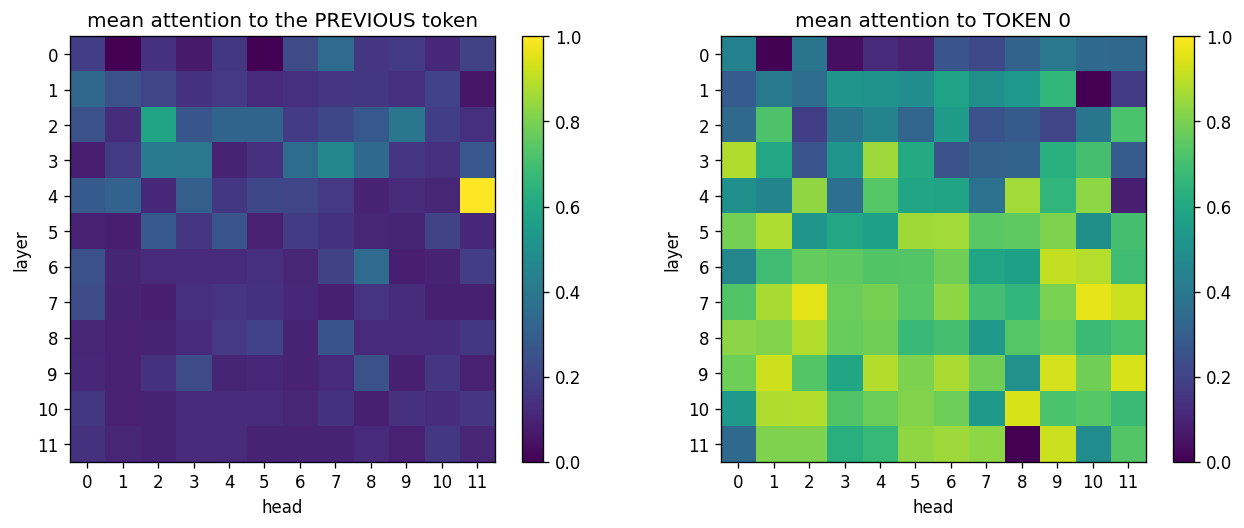

In [7]:
@torch.no_grad()
def get_attention(text: str):
    enc = tok(text, return_tensors="pt")
    out = model(**enc, output_attentions=True)
    assert out.attentions is not None and out.attentions[0] is not None, (
        "no attention weights returned: load the model with attn_implementation='eager'"
    )
    labels = [t.replace("Ġ", "_") for t in tok.convert_ids_to_tokens(enc["input_ids"][0])]
    return labels, out.attentions  


TEXT = PROMPT
labels, atts = get_attention(TEXT)
n = len(labels)
print(f"{n} tokens: {labels}")
print(f"{len(atts)} layers; each tensor has shape {tuple(atts[0].shape)} = (batch, heads, query, key)")
print("row sums, layer 0 head 0:", [round(x, 4) for x in atts[0][0, 0].sum(dim=-1).tolist()])


prev_score = torch.zeros(cfg.n_layer, cfg.n_head)
sink_score = torch.zeros(cfg.n_layer, cfg.n_head)
for L in range(cfg.n_layer):
    a = atts[L][0]  
    prev_score[L] = torch.stack([a[:, i, i - 1] for i in range(1, n)]).mean(dim=0)
    sink_score[L] = a[:, 1:, 0].mean(dim=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, score, title in [
    (axes[0], prev_score, "mean attention to the PREVIOUS token"),
    (axes[1], sink_score, "mean attention to TOKEN 0"),
]:
    im = ax.imshow(score.numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("head")
    ax.set_ylabel("layer")
    ax.set_xticks(range(cfg.n_head))
    ax.set_yticks(range(cfg.n_layer))
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

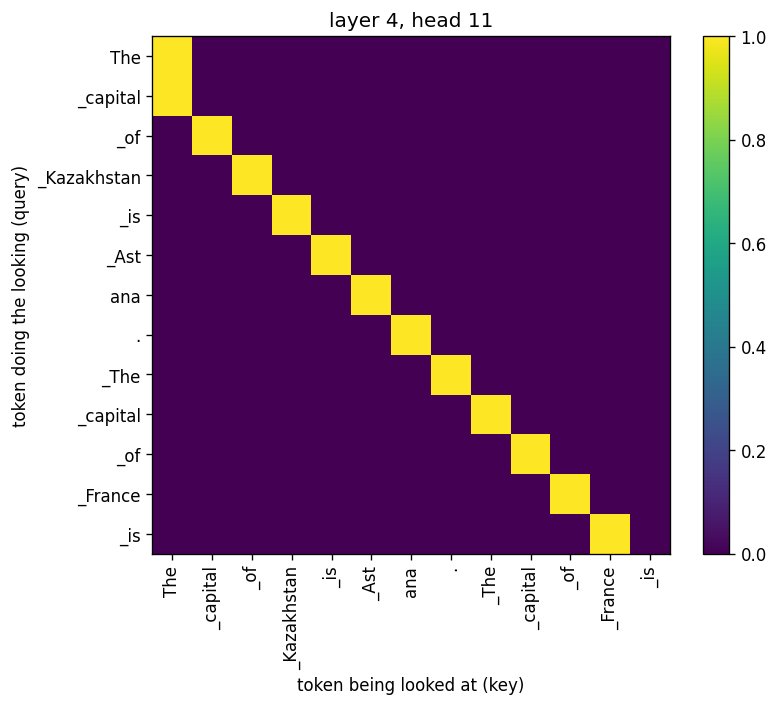

In [8]:
def attention_heatmap(text: str, layer: int, head: int) -> None:
    labels, atts = get_attention(text)
    a = atts[layer][0, head]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(a.numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("token being looked at (key)")
    ax.set_ylabel("token doing the looking (query)")
    ax.set_title(f"layer {layer}, head {head}")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()

LAYER, HEAD = 4, 11  
attention_heatmap(TEXT, LAYER, HEAD)


**✏️ Your answers.**

1. Read the left grid above. Which (layer, head) looks most like a "previous-token" head? Put it into `LAYER, HEAD` in the cell above and re-run it. What pattern do you see in the heatmap, and why is it a diagonal just *below* the main diagonal?
2. Does every head in that layer do the same thing?

> **1.** Layer 4, head 11 has the strongest previous-token pattern. In the heatmap I can see a bright diagonal line that is one step below the main diagonal. This happens because each token is mostly looking at the token right before it — so token at row i looks at column i-1.
>
> **2.** No, not at all. Other heads in layer 4 have very different patterns. Some look more at token 0, others are more spread out. Each head seems to learn something different.


In [9]:

for v, idx in zip(*torch.topk(prev_score.flatten(), 3)):
    L, H = divmod(idx.item(), cfg.n_head)
    print(f"layer {L}, head {H}: {v.item():.3f} of its attention goes to the previous token")

layer 4, head 11: 1.000 of its attention goes to the previous token
layer 2, head 2: 0.585 of its attention goes to the previous token
layer 3, head 7: 0.462 of its attention goes to the previous token


most extreme head on the RIGHT grid: layer 7, head 10  (mean attention to token 0 = 0.964)
mean attention to token 0, averaged over the 12 heads of each layer:
   [0.25, 0.42, 0.4, 0.52, 0.57, 0.72, 0.71, 0.81, 0.74, 0.79, 0.75, 0.66]


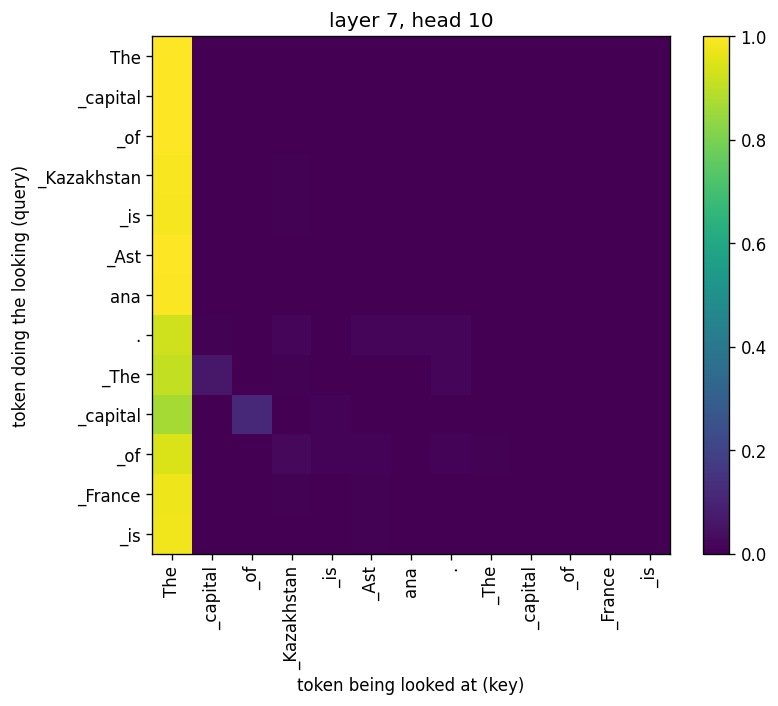

In [10]:
sink_layer, sink_head = divmod(sink_score.argmax().item(), cfg.n_head)
print(f"most extreme head on the RIGHT grid: layer {sink_layer}, head {sink_head}  "
      f"(mean attention to token 0 = {sink_score[sink_layer, sink_head]:.3f})")
print("mean attention to token 0, averaged over the 12 heads of each layer:")
print("  ", [round(x, 2) for x in sink_score.mean(dim=1).tolist()])
attention_heatmap(TEXT, sink_layer, sink_head)

### Two traps

**The bright first column.** In layers 5–10 the *average* head puts roughly 70–80% of its attention on token 0 (measured above, for this prompt), and the most extreme head puts over 95% there. That is not "the model is thinking about the word *The*". The usual explanation — which this lab does not test — is that a softmax row must sum to 1, so a head with nothing useful to look at has to put its weight somewhere, and the first token is where it goes. Either way, the bright column tells you how the mechanism is built, not what the first word means. Which head is the most extreme one changes from text to text; the phenomenon does not.

**A weight is not an explanation.** A high attention weight says how much of a token's *value vector* is averaged in. It does not say how much that token changed the answer. Lecture 3 cited the papers that argue about this; the heatmap is a picture of a mechanism, not a proof of a reason.

**✏️ Your answer.** Which layers have the highest average attention to token 0? Given the trap above, would you report "the model focuses on the first word" to a manager? What would you say instead?

> **Answer:** Layers 5 to 10 have the highest average attention to token 0. I wouldn't say the model focuses on the first word — that's misleading. I would say that attention scores in middle layers tend to concentrate on position 0, but this is probably just because softmax needs to put the weight somewhere when there's nothing specific to look at, not because the word "The" is important.


## Part 3 — the same model, in Kazakh (5 min)

Lecture 3's claim: Kazakh costs more because of the **table**, not the language. GPT-2's table has only
50,257 entries; how well it covers Russian and Kazakh is what you measure now. Three parallel sentences
(my translations — if you spot an error, say so):

**✏️ Predict first.** Which language needs the most tokens *per character*? Lecture 3 (slide 2) measured Kazakh at
1.7–4.8× the English token count and Russian at 1.2–2.9×, across six tokenizers. Will Kazakh be clearly worse than
Russian on GPT-2 as well?

> **Prediction:** Yes, I think Kazakh will need more tokens per character than Russian. Kazakh has extra letters like Қ, ұ, ң that Russian doesn't have, so GPT-2's table probably covers Kazakh even worse. Maybe Kazakh will be 2x worse than Russian.


In [11]:
SENTENCES = {
    "en": "The capital of Kazakhstan is Astana.",
    "ru": "Столица Казахстана — Астана.",
    "kk": "Қазақстанның астанасы — Астана.",
}

print(f"{'lang':<5}{'chars':>6}{'bytes':>7}{'tokens':>8}{'tokens/char':>13}{'x English':>11}")
en_tokens = len(tok.encode(SENTENCES["en"]))
for lang, s in SENTENCES.items():
    t = len(tok.encode(s))
    print(f"{lang:<5}{len(s):>6}{len(s.encode()):>7}{t:>8}{t / len(s):>13.2f}{t / en_tokens:>11.2f}")

lang  chars  bytes  tokens  tokens/char  x English
en       36     36       8         0.22       1.00
ru       28     53      31         1.11       3.88
kk       31     59      34         1.10       4.25


In [12]:
@torch.no_grad()
def greedy_continue(prompt: str, n_tokens: int = 20) -> str:
    """Slide 14's loop, written out: pick the #1 token, append it, repeat."""
    ids = tok(prompt, return_tensors="pt")["input_ids"]
    for _ in range(n_tokens):
        next_id = model(input_ids=ids).logits[0, -1].argmax()
        ids = torch.cat([ids, next_id.view(1, 1)], dim=1)
    return tok.decode(ids[0])


for prompt in ["The capital of Kazakhstan is", "Столица Казахстана —", "Қазақстанның астанасы —"]:
    show_next_token(prompt, k=3)
    top1 = int(next_token_logits(prompt).argmax())
    print(f"  #1 token as raw text: {tok.convert_ids_to_tokens(top1)!r}")
    print("  greedy, 20 tokens:", repr(greedy_continue(prompt)))
    print()

prompt: 'The capital of Kazakhstan is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   8.98%   id    262   ' the'
   7.63%   id   1363   ' home'
   5.89%   id    257   ' a'
  top-3 hold 22.5%; the other 50,254 tokens share 77.5%
  #1 token as raw text: 'Ġthe'
  greedy, 20 tokens: "The capital of Kazakhstan is the capital of the country's former Soviet Union, and the country's president, Nursultan Nazar"

prompt: 'Столица Казахстана —'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  37.79%   id  12466   ' �'
   2.40%   id    198   '\n'
   2.34%   id    220   ' '
  top-3 hold 42.5%; the other 50,254 tokens share 57.5%
  #1 token as raw text: 'ĠÐ'
  greedy, 20 tokens: 'Столица Казахстана — Столица Казахста'

prompt: 'Қазақстанның астанасы —'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  22.54%   id  12466   ' �'
   4.11%   id    220   ' '
   2.39%   id    198   '\n'
  top-3 hold 29.0%; the other 50,254 tokens share 71.0%
  #1 token as raw te

**✏️ Your answer.** One or two sentences. Look at the `tokens/char` column and at the #1 next token for the
Russian and Kazakh prompts. What does the model see, and why does it break? Is the problem the Kazakh
*language*, or something else? What would you change to fix it?

> **Answer:** The tokens/char is about the same for Russian and Kazakh (both around 1.1), but both are much worse than English. The model breaks on Cyrillic text because it wasn't trained on enough Russian or Kazakh data, and the byte-level pieces it produces don't form real words. The problem is the training data and small vocabulary, not the language itself. To fix it you would need a model trained on more multilingual text, like mGPT or a modern multilingual model.


## What you hand in

Download this notebook (*File → Download → .ipynb*) **after** you have run every cell and filled in every ✏️, and upload it to Canvas.

1. The four predictions (Parts 0, 1, temperature, 3), written before you ran the cell, with the measured value next to each.
2. Your one-sentence difference between temperature and top-p.
3. The (layer, head) you found for the previous-token pattern, and the (layer, head) of the most extreme "token 0" head.
4. Your Part 3 answer.

Extension tasks are in the README of this repository. They are optional.